# Coursework Set Week 5

**Common remarks**:

* Deadline: Sunday at 23:59h for the scheduled week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Ylou Mesu
* Username: ymmesu
* Student number: S6358179
* Group (AS1, etc.): AS3

-----

succes met nakijken Tim!!!! 

(hallo )>             (:^D)-|--<

In [1]:
totalpoints = currentpoints = 0

### Plotting a galaxy rotation curve from data in a text file (4 pt) <font color='red'><b>COURSEWORK</b></font>

This qustion you will use data from an observation of NGC 6946. The stellar mass of NGC 6946 is $M_* = 2\times10^{10} M_{\odot}$, where $M_{\odot}$ represent *solar mass (the mass of the Sun)*. 

* Copy/download the file [rotcur.dat](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/rotcur.dat). This text file contains the output of a program that calculates rotation curves. Examine its contents on the Linux command line with a pager like ``more`` or in an editor so that you know what the columns represent.
* Write a program, that reads the columns `radius` and `rotation velocity`. Radii are in **kpc** and velocities in **km/s**.
* Create a line plot where the $x$-axis represents the radius and the $y$-axis represents the rotation velocity.
* Calculate the Keplerian rotation curve using $v=\sqrt{\frac{GM}{r}}$
* Create and save a text file called ``keplerian_curve.txt`` using ``np.savetxt()``.
* Using ``np.loadtxt()`` to load your Keplerian curve and plot it together with the observation data.
* Force the lower limit of the $y$-axis range to 0 and the upper limit to maximal values of the Keplerian curve.
* Annotate the plot with relevant information.
* Make comment about your observation.

**Answers**:

(341, 2)


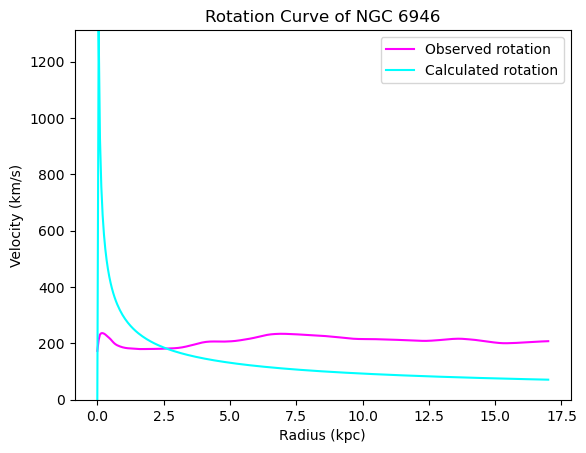

 we can clearly see that the observed and calculated data dont allign very well,
 this is because R gets a lot bigger and we assume M and G to be constant, and thus the velocity to drop off.
 this does not happen in our observed data leaving many sientist to believe that there must be more matter than we see
 dark matter.
 some might also believe that just dont know enough about gravity.


In [2]:
import numpy as np
from matplotlib import pyplot as plt
import math
from scipy.constants import G


 
    
M_sun = 1.989e30
M = 2e10 * M_sun

#to convert the radius in kpc to meter
kpc_to_m = 3.086e19

#uploading the file we are working with ( never put an 'w'there it wil erease everything )
data = np.loadtxt("rotcur.dat", comments="#", ndmin=2)


#Checking data ( never ever put 'w' in there if you are not sure)
print(data.shape)

#making the radius and velocity 2 seperate lists
radius = data[:,0]

rotvel = data[:,1]

#creating a list to put the calculated velocities in later
calcrotvel = []

#calculating the velocities using the radius and solar mass given
for r in radius:
    if r == 0:
        calcrotvel.append(0)
        continue

    r_in_m = r * kpc_to_m
    v = math.sqrt((G*M)/r_in_m)
    calcrotvel.append(v/1000)

    

#creating a text file with the radius and the calculated rotational velocity
kepler = np.column_stack((radius, calcrotvel))
np.savetxt("keplerian_curve.txt", kepler)

#making lists like we did before but now from the calculated data
calcdata = np.loadtxt("keplerian_curve.txt")
calcradius = calcdata[:,0]
calcrotvel1 = calcdata[:,1]


#plotting and trotting
plt.plot(radius, rotvel, label="Observed rotation", color = "magenta")
plt.plot(calcradius, calcrotvel1, label="Calculated rotation", color = "aqua")
plt.xlabel("Radius (kpc)")
plt.ylabel("Velocity (km/s)")
plt.ylim(0, max(calcrotvel1))
plt.title("Rotation Curve of NGC 6946")
plt.legend()
plt.show()

print(' we can clearly see that the observed and calculated data dont allign very well,\n this is because R gets a lot bigger and we assume M and G to be constant, and thus the velocity to drop off.\n this does not happen in our observed data leaving many sientist to believe that there must be more matter than we see\n dark matter.\n some might also believe that just dont know enough about gravity.')

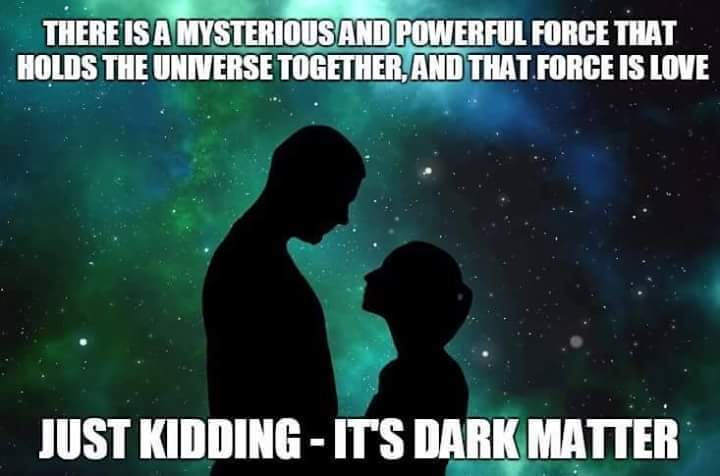

In [3]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Exploring image noise (3 pt)  <font color='red'><b>COURSEWORK</b></font>
   
* Create a two dimensional NumPy array with 200 rows and 300 columns filled with pixel values drawn from the normal distribution ``numpy.random.normal()`` with a mean of 0 and standard deviation 1.0.
* Use ``plt.imshow()`` to plot the image. The figure must be 8 inches wide and 4 inches high.
* Use color map ``jet`` for your image.
* Take a small two dimensional slice (e.g. 30x30 pixels) somewhere in the image and calculate the mean and standard deviation of the pixel values in your slice.
* Are this mean and standard deviation what you expected?
* Plot a histogram of all image values in 50 bins (you will need to ravel/flatten the data first). To not overlap with the previous plot, you probably need to create a new plot ``plt.figure()``. What distribution should you recognise?

**Answer**:

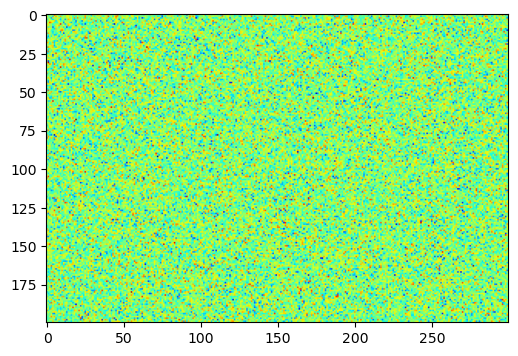

the mean is: -0.03 and the standard deviation is: 1.05
The mean and standard deviation are as thet were expected because they are similar to the mean and standard deviation assigned to the original array


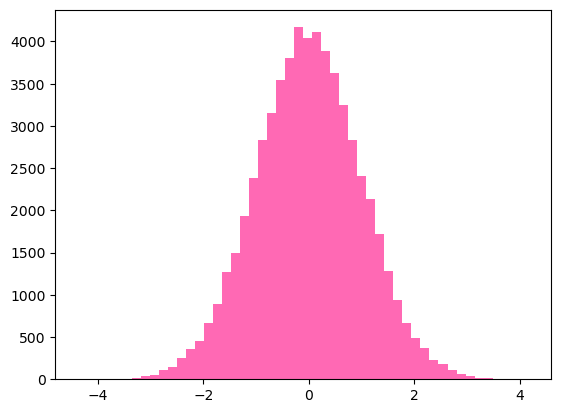

In [4]:
import numpy as np
import matplotlib.pyplot as plt

#Creating a random array with 200 rows and 300 columns
s = np.random.normal(0, 1, (200,300))

#plotting the image with the correct size asked for by the question
plt.figure(figsize=(8,4))
plt.imshow(s, cmap="jet")
plt.show()

#Taking a smaller slice and calculating its mean and standard deviation
s_part = s[30:60, 30:60]
s_part_mean = np.mean(s_part)
s_part_stdev = np.std(s_part)

print(f"the mean is: {s_part_mean:.2f} and the standard deviation is: {s_part_stdev:.2f}")

#conclusion about the calculated mean and stdev
print("The mean and standard deviation are as thet were expected because they are similar to the mean and standard deviation assigned to the original array")

#plotting the histogram of the slice
plt.figure()
plt.hist(s.flatten(), bins=50, color="hotpink")
plt.show()

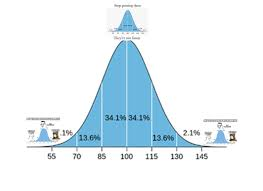

In [5]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

### Extending the Ellipse class (6 pt) <font color='red'><b>COURSEWORK</b></font>

* Copy the code for class ``AstroEllipse`` in the section.
* Extend the class with a method that calculates and returns the area of the ellipse.
* Extend the class with a method that calculates and returns the perimeter of the ellipse (keywords: Ramanujan’s formula for perimeter of ellipse).
* Give an example of the creation of an ellipse with semi major axis equal to 3 and semi minor axis equal to 2 and call the methods for area and perimeter to show what the area and perimeter is for this ellipse.
* Add a method ``__str__()`` which returns a string with the values of the ellipse parameters (center, axes and angle) and demonstrate the method with ``print()``.
* Create a class ``MyCircle`` which inherits from class ``AstroEllipse``. The arguments for its ``__init__()`` function is a center position and a radius.
* Create a plot with three circles with random origins and radii. The circles must have different colors and the  transparency (``alpha=``) must be set to 0.5. Use the ``Axes`` object (Section 5.7) to add the circles to the plot.

**Answers**:

Ellipse(center=(0,0), a=3, b=2, angle=0)
The area of the ellipse is  18.85
The perimeter of the ellipse is  15.87


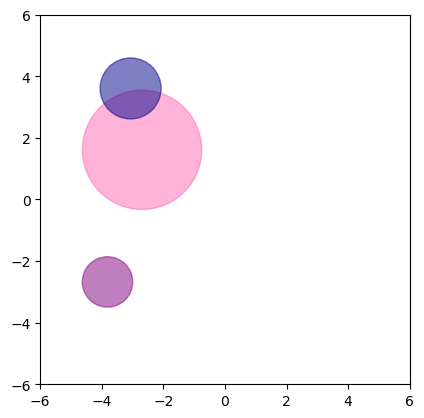

In [6]:
from matplotlib.patches import Ellipse
from scipy.constants import pi
import math
import matplotlib.pyplot as plt
import random

#Using the ellipse class and adding a function 
class AstroEllipse(Ellipse):
    def __init__(self, xc, yc, semi_major, semi_minor, position_angle, **args):
        assert(semi_major >= semi_minor)

        self.xc = xc
        self.yc = yc
        self.semi_major = semi_major
        self.semi_minor = semi_minor
        self.position_angle = position_angle

        XY = (xc, yc)
        height = 2.0 * semi_major
        width = 2.0 * semi_minor    
        super().__init__(XY, width, height, angle = position_angle, **args)

    #function that calculates the area of the ellipse
    def area(self):
        return pi * self.semi_major * self.semi_minor

    #function that calculated the perimeter of the ellipse
    def perimeter(self):
        a = self.semi_major
        b = self.semi_minor
        h = (a - b)**2/(a + b)**2
        P = pi*(a + b)*(1+ 3*h/(10 + math.sqrt(4-3*h)))
        return P

    #creates a string that will print what we put in(axes, angle)
    def __str__(self):
        s = f"Ellipse(center=({self.xc},{self.yc}), a={self.semi_major}, b={self.semi_minor}, angle={self.position_angle})"
        return s   

#an example ellipse
ellipse = AstroEllipse(0, 0, 3, 2, 0)

#printing the example ellipse and the area and perimeter
print(ellipse)
print(f"The area of the ellipse is {ellipse.area(): .2f}")
print(f"The perimeter of the ellipse is {ellipse.perimeter(): .2f}")


#creating a new class that creates circles using the ellipse class
class MyCircle(AstroEllipse):
    def __init__(self, xc, yc, radius, **args):
        super().__init__(xc, yc, radius, radius, 0, **args)

#creates subplots so we can easily plot multiple multiple plots in a single figure
fig, ax = plt.subplots()

#creating the different colors so we can see the different circles
colors = ["purple", "hotpink", "darkblue"]


for i in range(3):
    #returns a random number in the given range to determine where the center of the circles are
    xc = random.uniform(-5, 5)
    yc = random.uniform(-4, 4)
    r = random.uniform(0, 2)

    #plotting the different circles with the different values given
    circle = MyCircle(xc, yc, r, color=colors[i], alpha=0.5)
    ax.add_patch(circle)

#give the limits of the axes and makes the circles actual circles and not ellipses
ax.set_aspect("equal")
ax.set_xlim(-6, 6)
ax.set_ylim(-6, 6)

plt.show()

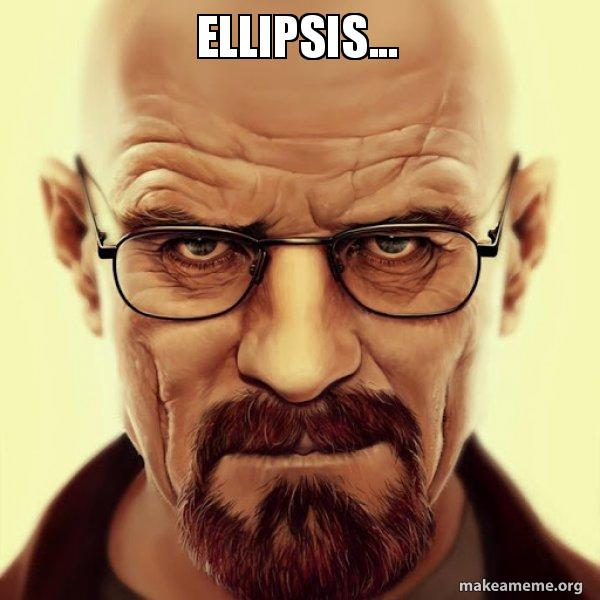

In [7]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

### Plotting Bessel's function (3 pt) <font color='red'><b>COURSEWORK</b></font>
   
The differential equation of Bessel is:

$$x^2\ \frac{d^2y}{dx^2}+x\ \frac{dy}{dx}+(x^2-a^2)y=0$$

Solutions of this equation are called Bessel functions of the first kind of real order ``a``.
Bessel functions are especially important for problems of wave propagation and static 
potentials and in solutions to the radial Schrodinger equation in quantum mechanics. 

Module ``special`` in package SciPy provides Bessel functions with the import statement:

```python
from scipy.special import jv
```

Write code that plots a solution of Bessel's differential equation for ``a=1,2,3`` and ``a=4`` on the interval ``x=[0,10]``in a mosaic of 2x2 plots. A Bessel function has arguments: ``jv(a, x)`` 

<font color='red'>Note: Object Oriented Plotting is required, or 1.0pt will be deducted.</font>

* Annotate your plot with a title and labels for the $x$- and $y$ axis. 
* Add a legend with labels for all curves.
* Include code that saves your figure to a file with base name ``bessel`` as a transparent PNG file.
* Attach the figure (PNG file) in the notebook.

**Code and figure**:

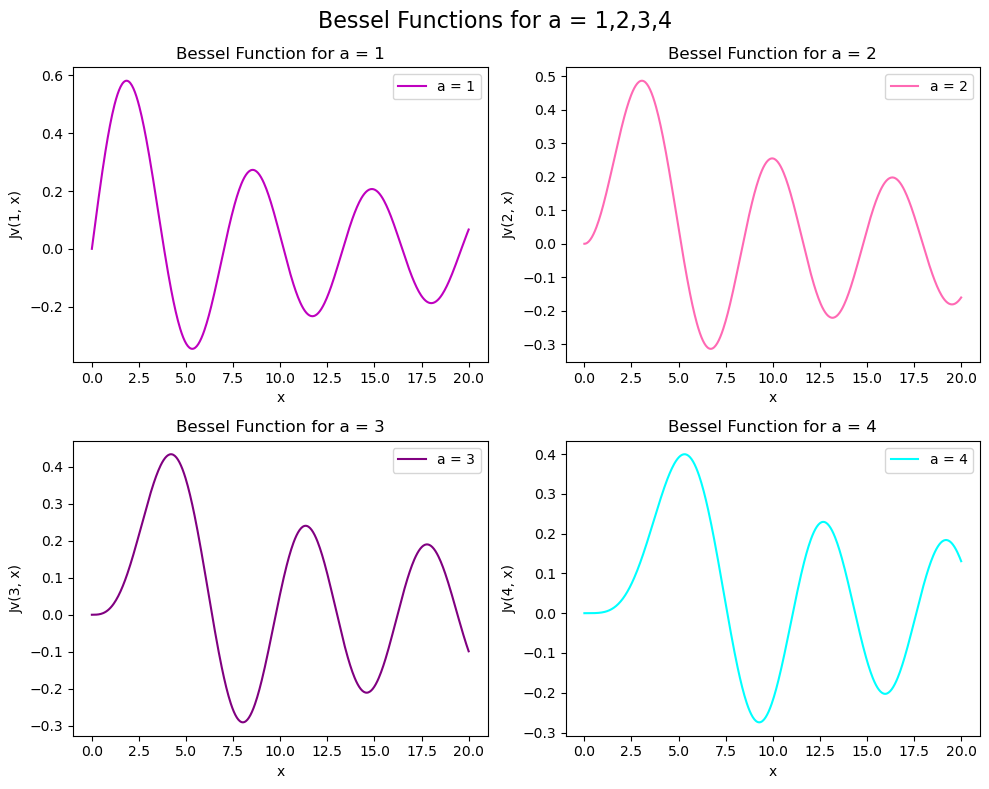

In [8]:
from scipy.special import jv
import numpy as np
from matplotlib import pyplot as plt

#creating an array of different numbers to make a smooth plot
x = np.linspace(0, 20, 500)

#creating a list for a=1,2,3,4 so I can later make a loop that loops through these numbers for the bessel functions
numbersa = [1, 2, 3, 4]



#making a list for colors so the graphs can have different colors :D
colors = ["m", "hotpink", "purple", "cyan"]

#creating the subplot so I can have 4 plots in 1 figure
fig, axs = plt.subplots(2, 2, figsize=(10, 8))




#flattening the axes so looping will be easier later
axs = axs.flatten()

#making a loop that creates the plots and enters the values into the bessel function
for ax, a, c in zip(axs, numbersa, colors):
    y = jv(a, x)
    ax.plot(x, y, color=c, label=f"a = {a}")
    ax.set_xlabel("x")
    ax.set_ylabel(f"Jv({a}, x)")
    ax.set_title(f"Bessel Function for a = {a}")
    ax.legend()



#giving the entire figure a title   
fig.suptitle("Bessel Functions for a = 1,2,3,4", fontsize=16)

#making sure the individual plots dont overlap
fig.tight_layout()

#saving the figure
plt.savefig("bessel.png", transparent=True)

plt.show()

er valt niet zo veel grappigs te zeggen over bessels function...............

In [9]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

### Matplotlib, the right way (2 pt)  <font color='red'><b>HOMEWORK</b></font>

The following table contains the measurements of distances and velocities, including their uncertainties, for a small sample of galaxies. The table is given in the form of a Python list.

From your previous coursework, you have done chi-squared fitting to fit the following data without uncertainties. If considering the uncertainties during the fitting process, the slope of a best fit line through the data gives a value for the Hubble constant.

$$H_0 = 67.8 (km/s)/Mpc$$

```
    d(Mpc)    v(km/s)    error in d    error in v
    ==============================================
    18.49      2094.75    0.3           100
    35.48      2320.87    2.2           120
    ........
```
```python
    data = [
    18.49,     2094.75,    0.3,           100,
    35.48,     2320.87,    2.2,           120,
    35.48,     1224.9,     3.0,           80,
    11.34,     872.13,     1.2,           80,
    7.12,      432.2,      0.4,           70,
    9.82,      751,        0.3,           75,
    23.66,     1410,       2.3,           70,
    44,        2700,       4.0,           110,
    66.7,      5292,       5.3,           120,
    52.4,      2550,       5.2,           100,
    55,        5253,       6.1,           150,
    25.6,      2419,       3.2,           110,
    26.19,     2158,       2.8,           110
    ]
```

<font color='red'>In this question, you have to use the OO interface of Matplotlib to create your plot, or 1.0pt will be deducted.</font>

* Use slicing syntax to unpack ``data`` into separate variables for distance and velocity, as well as their corresponding errors.
* Create a plot for this data. Add error bars with method `errorbar() <matplotlib.axes.Axes.errorbar>`
* Plot also a line which represents the Hubble relation between distance and velocity  as a line through the origin, with a slope equal to $H_0$
* Add the value of $H_0$ to the legend using LaTex math mode
  
**Script and plot**:

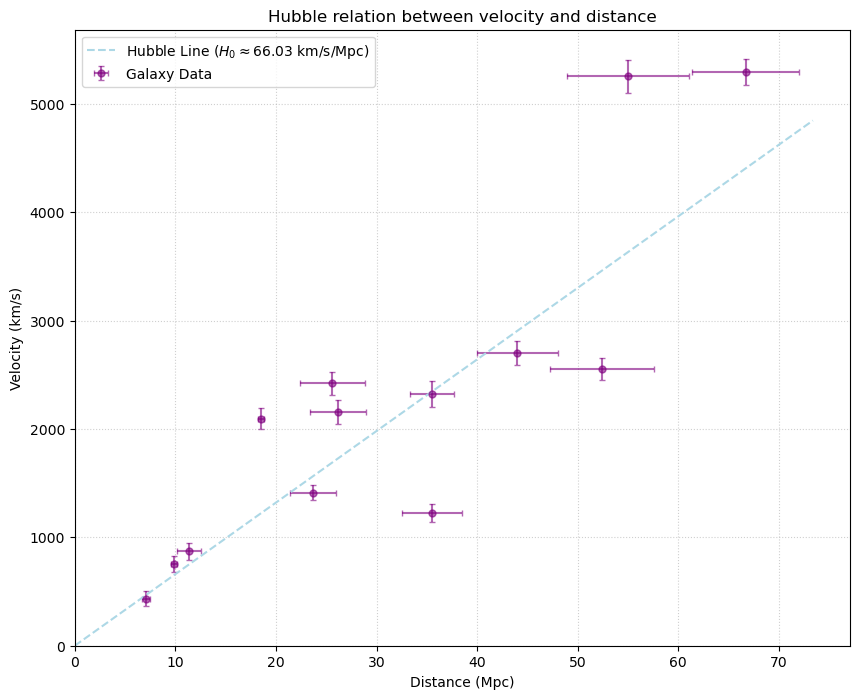

In [10]:
from matplotlib import pyplot as plt
import numpy as np

#the data used for this code 
data = [
   18.49,     2094.75,    0.3,           100,
   35.48,     2320.87,    2.2,           120,
   35.48,     1224.9,     3.0,           80,
   11.34,     872.13,     1.2,           80,
   7.12,      432.2,      0.4,           70,
   9.82,      751,        0.3,           75,
   23.66,     1410,       2.3,           70,
   44,        2700,       4.0,           110,
   66.7,      5292,       5.3,           120,
   52.4,      2550,       5.2,           100,
   55,        5253,       6.1,           150,
   25.6,      2419,       3.2,           110,
   26.19,     2158,       2.8,           110
]

#Creating seperate lists, and making them arrays, of all the columns, so we have velocity, distance and their errors seperated
d = np.array(data[0::4])
v = np.array(data[1::4])
ed = np.array(data[2::4])
ev = np.array(data[3::4])

#calculating the hubble constant with a weighted velocity uncertainty so the fit as accurate as possible. 
weight = 1 / ev**2
h0 = np.sum(weight * v * d) / np.sum(weight * d**2)

#creating a plot using object oriented interface
fig, ax = plt.subplots(figsize=(10, 8))

#adding the errorbars
ax.errorbar(d, v, xerr=ed, yerr=ev, alpha = 0.6 , fmt = "o", capsize=2, label="Galaxy Data", color="purple", markersize=5)

#making a continuous line for the fit of the different values we've gotten and then plotting the line
dH0 = np.linspace(0, max(d) * 1.1, 100)
vH0 = h0 * dH0
ax.plot(dH0, vH0, color="lightblue", linestyle="--", label=rf"Hubble Line ($H_0 \approx {h0:.2f}$ km/s/Mpc)")

#plotting the graph and making it good-looking
ax.set_title("Hubble relation between velocity and distance")
ax.set_xlabel("Distance (Mpc)")
ax.set_ylabel("Velocity (km/s)")
#making sure the plot starts at the origin
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
ax.grid(linestyle=":", alpha=0.6)
ax.legend()

plt.show()

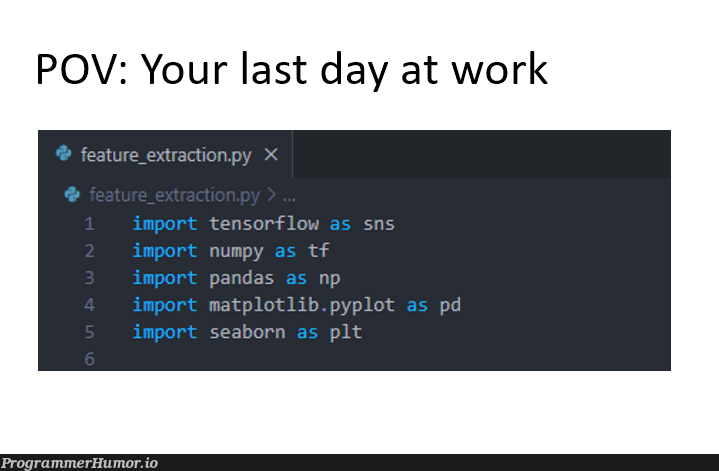

In [11]:
# Leave unaltered
totalpoints += 2
currentpoints += 0.0

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [12]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")

Total number of points: 18. Student score: 0.0.  Task Grade = 0.0


<div>
<img scr="attachment:welp.jpg" width="1000")/>
</div>

<img src="welp.jpg" width="10000">